# Adversarial Attack


На лекции мы разобрались, что ML-модели можно атаковать. Например, в задаче распознавания лиц мы можем добавить к изображению небольшой шум, который заставит модель совершить ошибку.

В этом задании мы научимся защищать модель от атак. Для иллюстрации мы будем использовать простую логистическую регрессию, но похожие идеи можно применить и к сложным нейросетям.

В качестве задачи рассмотрим классификацию изображений MNIST для цифр 0 и 1.

### Подготовка

In [112]:
# Загрузим библиотеки, которые нам пригодятся

import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")

In [113]:
# Загрузим датасет
mnist = fetch_openml('mnist_784', as_frame=False, cache=True)

# подготовим данные в нужном формате
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

# Оставим в датасете только классы 0 и 1
y_bin = y[(y == 0) | (y == 1)]
X_bin = X[(y == 0) | (y == 1)]

# Для удобства, обозначим лейблы классов за -1 (обозначает цифру 0)
# и 1 (обозначает цифру 1)
y_bin[y_bin == 0] = -1

# Посмотрим на долю единиц в датасете
positive_class_size = len(y_bin[y_bin == 1])
positive_class_rate = positive_class_size / len(y_bin)

print("Доля единиц в датасете: ", positive_class_rate)

Доля единиц в датасете:  0.5329499323410013


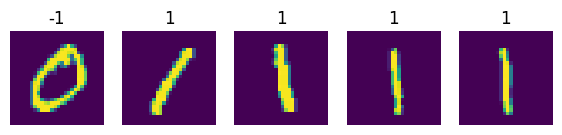

In [114]:
# Посмотрим на первые 5 примеров

n = 5

fig, axs = plt.subplots(1, n, figsize=(7, 3))

for ax, image, label in zip(axs, X_bin[:n], y_bin[:n]):
    # Переводим картинку из вектора длины 784 в матрицу 28 x 28
    image_reshaped = image.reshape(28, 28)

    ax.imshow(image_reshaped)
    ax.set_title(label)
    ax.axis("off")

### Шаг 1. Тренировка незащищенной модели [2 балла]


Начнем с того, что натренируем стандартную модель логистической регрессии и оценим ее устойчивость к атакам. Из курса ML вспомним, что логистическая регрессия это линейная модель:

$$h_\theta(x) = w^T x + b$$

с функцией ошибки

\begin{equation}
\ell(h_\theta(x), y) = \log(1+\exp(-y\cdot h_\theta(x))) \equiv L(y \cdot h_\theta(x))
\end{equation}

Здесь для сокращения записи мы ввели функцию $L(x) = \log(1+\exp(-x))$.


**Что нужно сделать:**

1. Разбить данные на train и test

2. Нормализовать датасет ($X$) так, чтобы значения каждого пикселя были в диапазоне [0, 1]

3. Натренировать модель логистической регрессии на train set

4. Оценить точность (accuracy) логистической регрессии на test set

Для решения этой части задания можно использовать встроенные методы `sklearn`



In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(X_bin, y_bin)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_simple_regression = LogisticRegression()
model_simple_regression.fit(X_train, y_train)

model_simple_regression.score(X_test, y_test)

0.9983761840324763

### Шаг 2. Атака незащищенной модели [3 балла]

Будем считать, что мы можем атаковать модель, изменив значение каждого пикселя в изображении не более чем на 0.2 (атака производится после нормализации):

$$x' = x + \delta, \quad ||\delta||_{\infty} \le 0.2 = \epsilon.$$

Как мы доказали на лекции, в случае логистической регрессии мы можем найти точное выражение для оптимальной атаки:
\begin{equation}
\delta^\star = - y \cdot \epsilon \cdot \mathrm{sign}(w),
\end{equation}
где $w$ это вектор весов модели, который мы получили на Шаге 1.

Давайте проведем атаку на модель и посмотрим как сильно упадет её точность.

**Что нужно сделать**

1. Вычислить значения оптимальной атаки $\delta^\star$ для каждого класса (-1 и 1)

2. Применить атаку к каждому изображению в test set

3. Оценить точность (accuracy) логистической регрессии на атакованном test set

Обратите внимание, что атака изображения может вывести значения пикселей из диапазона $[0, 1]$. Для простоты в этом задании можно не делать повторной нормализации.

Для решения этой части задания можно использовать встроенные методы `sklearn`

In [116]:
params = model_simple_regression.coef_
epsilon = 0.2
delta_star_test = - np.outer(y_test, params) * epsilon
X_test_hacked = X_test + delta_star_test

model_simple_regression.score(X_test_hacked, y_test)

0.9902571041948579

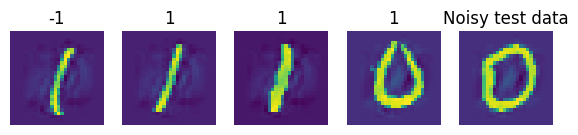

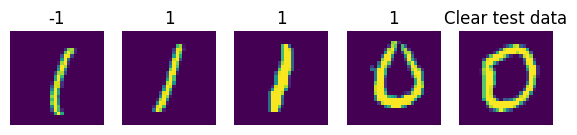

In [117]:
n = 5

fig, axs = plt.subplots(1, n, figsize=(7, 3))
X_test_hacked_unscaled = scaler.inverse_transform(X_test_hacked)
for ax, image, label in zip(axs, X_test_hacked_unscaled[:n], y_bin[:n]):
    # Переводим картинку из вектора длины 784 в матрицу 28 x 28
    image_reshaped = image.reshape(28, 28)

    ax.imshow(image_reshaped)
    ax.set_title(label)
    ax.axis("off")
plt.title('Noisy test data')
plt.show()

fig, axs = plt.subplots(1, n, figsize=(7, 3))
X_test_unscaled = scaler.inverse_transform(X_test)
for ax, image, label in zip(axs, X_test_unscaled[:n], y_bin[:n]):
    # Переводим картинку из вектора длины 784 в матрицу 28 x 28
    image_reshaped = image.reshape(28, 28)

    ax.imshow(image_reshaped)
    ax.set_title(label)
    ax.axis("off")
plt.title('Clear test data')
plt.show()

In [118]:
np.unique(y_train)

array([-1,  1])

С учётом того, что раньше модель ошибалась, наверное, в пределах погрешности, сейчас модель просто начала ошибаться. Accuracy 0.97 кажется всё равно очень высоким, но и задача простая.


### Шаг 3. Тренировка Robust Classifier [5 баллов]

Чтобы натренировать модель, устойчивую к атакам, нужно изменить процесс тренировки. Во время тренировки нам нужно минимизировать не стандартную функцию ошибки логистической регрессии, а модифицированную:

\begin{equation}
\DeclareMathOperator*{\minimize}{minimize}
\minimize_{w,b} \frac{1}{D}\sum_{(x,y) \in D} L \left(y \cdot (w^Tx + b) - \epsilon \|w\|_1 \right ).
\end{equation}

Натренируйте модель Robust Logistic Regression на train set и оцените ее устойчивость к атакам.

**Что нужно сделать:**

1. Реализуйте свой ML-метод: класс **RobustLogisticRegression**, который наследует от sklearn класса [BaseEstimator](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html). Новый класс должен содержать методы `fit` и `predict`, а внутри метода `fit` должна проходить процедура градиентного спуска с новой функцией ошибки. Шаблон класса дан ниже.

2. Натренируйте Robust Logistic Regression и оцените ее точность на чистом test set

3. Вычислите атаку $\delta^\star = - y \cdot \epsilon \cdot \mathrm{sign}(w)$ на модель и проатакуйте test set. Для атаки используйте веса робастной модели

4. Оцените точность модели на атакованном test set

Для решения этой части задания **нельзя** использовать встроенные методы `sklearn`, только шаблон ниже и методы `numpy`

In [157]:
from sklearn.base import BaseEstimator


class RobustLogisticRegression(BaseEstimator):

    def __init__(self, fit_intercept=True, l1_coef=0.1, lr=1e-3, max_iter=100000, log_train_history=False, tol=1e-9):
        self.fit_intercept = fit_intercept
        self.l1_coef = l1_coef
        self.lr = lr
        self.max_iter = max_iter
        self.log_train_history = log_train_history
        self.tol = tol

        self.coef_ = None
        self.history_loss = []
        self.history_acc = []

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    def BCEloss(self, x):
        return np.mean(np.log(1 + np.exp(-x)))

    def BCEgrad(self, X, y, w):
        D = X.shape[0]
        P = 1 / (1 + np.exp(y * (X @ w) - self.l1_coef * np.sum(np.abs(w))))

        return (-X.T @ (y * P) + self.l1_coef * np.sign(w) * np.sum(P)) / D

    def fit(self, X, y):
        """Метод для тренировки модели по тренировочным данным X и y"""
        if self.fit_intercept:
            X = np.concat([np.ones([X.shape[0], 1]), X], axis=1)
        y_copy = y.copy()
        y_copy = y_copy.reshape(-1, 1)
        self.coef_ = np.zeros([X.shape[1], 1])

        for epoch in range(self.max_iter):
            if self.log_train_history:
                self.history_loss.append(self.BCEloss(y_copy * (X @ self.coef_) - self.l1_coef * np.sum(self.coef_)))
                self.history_acc.append(self.score(X, y_copy))
            grad = self.BCEgrad(X, y_copy, self.coef_)
            self.coef_ -= self.lr * grad

            if np.linalg.norm(grad) < self.tol:
                break

    def predict(self, X):
        """Метод для предсказания классов для данных X"""

        if self.coef_.shape[0] == X.shape[1] + 1:
            X = np.concat([np.ones([X.shape[0], 1]), X], axis=1)
        return RobustLogisticRegression.sigmoid(X @ self.coef_) > 0.5

    def score(self, X, y):
        preds = self.predict(X)
        y_copy = (y.reshape(-1, 1) + 1) / 2
        score = np.sum(preds == y_copy) / len(y_copy)
        return score

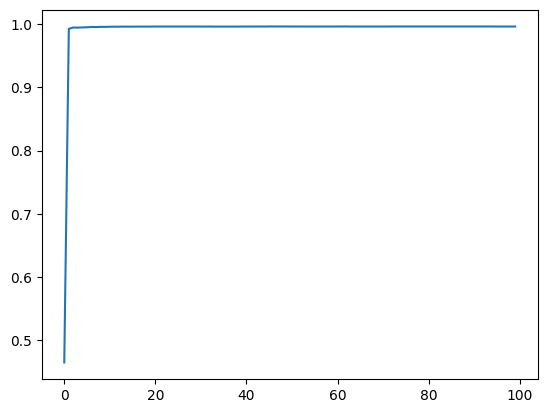

In [158]:
robust_model = RobustLogisticRegression(fit_intercept=True, log_train_history=True, max_iter=100)
robust_model.fit(X_train, y_train)
plt.plot(robust_model.history_acc)

In [159]:
robust_model.score(X_test, y_test)

np.float64(0.9953991880920162)

In [162]:
params = robust_model.coef_
epsilon = 0.2
delta_star_test = - np.outer(y_test, params) * epsilon
X_test_expanded = np.concat([np.ones([X_test.shape[0], 1]), X_test], axis=1)
X_test_hacked = X_test_expanded + delta_star_test

robust_model.score(X_test_hacked, y_test)

np.float64(0.9953991880920162)

Да, действительно, теперь наша атака вообще не уменьшиша Accuracy. Видимо, это победа. 